### Visualizing the image right before prediction

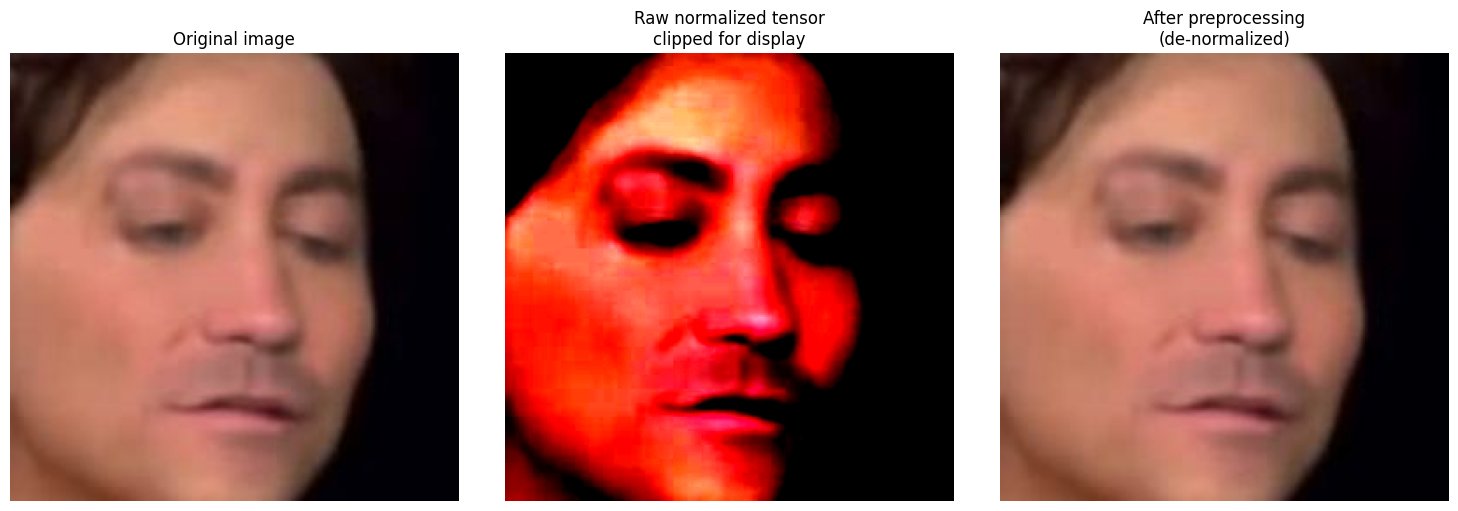

In [4]:
import random
from pathlib import Path

import torch
import matplotlib.pyplot as plt
from PIL import Image

from utils import get_dataset_roots, collect_images
from mlep_fast_evaluator import get_mlep_transform


def visualize_random_mlep_preprocessed_image(
    load_size=256,
    crop_size=224,
    no_resize=False,
    no_crop=True,
    seed=None,
):
    """
    Picks one random dataset, one random image, applies the exact MLEP preprocessing,
    and shows:
      1. original image
      2. preprocessed image after de-normalizing for visualization

    The actual tensor printed is the real tensor passed to the model.
    """

    if seed is not None:
        random.seed(seed)

    dataset_roots = get_dataset_roots()

    # Keep only datasets that exist and contain images
    valid_datasets = []
    for dataset_name, dataset_root in dataset_roots.items():
        dataset_root = Path(dataset_root)
        if not dataset_root.exists():
            continue

        samples = collect_images(dataset_root)
        if len(samples) > 0:
            valid_datasets.append((dataset_name, dataset_root, samples))

    if not valid_datasets:
        raise RuntimeError("No valid datasets found. Check your Datasets/ paths.")

    dataset_name, dataset_root, samples = random.choice(valid_datasets)
    sample = random.choice(samples)

    img_path = Path(sample["path"])
    original_img = Image.open(img_path).convert("RGB")

    transform = get_mlep_transform(
        load_size=load_size,
        crop_size=crop_size,
        no_resize=no_resize,
        no_crop=no_crop,
    )

    preprocessed_tensor = transform(original_img)          # [3, H, W]
    model_input_tensor = preprocessed_tensor.unsqueeze(0)  # [1, 3, H, W] -> this is passed to model

    # De-normalize only for visualization
    mean = torch.tensor([0.485, 0.456, 0.406]).view(3, 1, 1)
    std = torch.tensor([0.229, 0.224, 0.225]).view(3, 1, 1)

    raw_vis_tensor = preprocessed_tensor.cpu().clamp(0, 1)
    raw_vis_img = raw_vis_tensor.permute(1, 2, 0).numpy()

    denorm_tensor = preprocessed_tensor.cpu() * std + mean
    denorm_tensor = denorm_tensor.clamp(0, 1)
    denorm_img = denorm_tensor.permute(1, 2, 0).numpy()

    plt.figure(figsize=(15, 5))

    plt.subplot(1, 3, 1)
    plt.imshow(original_img)
    plt.title("Original image")
    plt.axis("off")

    plt.subplot(1, 3, 2)
    plt.imshow(raw_vis_img)
    plt.title("Raw normalized tensor\nclipped for display")
    plt.axis("off")

    plt.subplot(1, 3, 3)
    plt.imshow(denorm_img)
    plt.title("After preprocessing\n(de-normalized)")
    plt.axis("off")

    plt.tight_layout()
    plt.show()

    return {
        "dataset_name": dataset_name,
        "dataset_root": str(dataset_root),
        "image_id": sample["id"],
        "image_path": str(img_path),
        "true_label": sample["true_label"],
        "split": sample["split"],
        "model_input_tensor": model_input_tensor,
    }


sample_info = visualize_random_mlep_preprocessed_image()

### Finetuning and comparing results

In [5]:
from utils import get_dataset_roots

get_dataset_roots()

{'20K_real_and_deepfake_images': WindowsPath('c:/Extra_D/Ali_Master/Term 3/Computer Vision/Project/DeepFakeDetectionAndPrevention_AKA_DEEPFAKEPOLICE/Datasets/20K_real_and_deepfake_images'),
 'DeepDetect-2025': WindowsPath('c:/Extra_D/Ali_Master/Term 3/Computer Vision/Project/DeepFakeDetectionAndPrevention_AKA_DEEPFAKEPOLICE/Datasets/DeepDetect-2025/ddata'),
 'Deepfake-vs-Real-v2': WindowsPath('c:/Extra_D/Ali_Master/Term 3/Computer Vision/Project/DeepFakeDetectionAndPrevention_AKA_DEEPFAKEPOLICE/Datasets/Deepfake-vs-Real-v2'),
 'gravex200k': WindowsPath('c:/Extra_D/Ali_Master/Term 3/Computer Vision/Project/DeepFakeDetectionAndPrevention_AKA_DEEPFAKEPOLICE/Datasets/gravex200k/my_real_vs_ai_dataset/my_real_vs_ai_dataset'),
 'nuriachandra_Deepfake-Eval-2024': WindowsPath('c:/Extra_D/Ali_Master/Term 3/Computer Vision/Project/DeepFakeDetectionAndPrevention_AKA_DEEPFAKEPOLICE/Datasets/nuriachandra_Deepfake-Eval-2024')}

In [10]:
from finetune_mlep import finetune_mlep

result = finetune_mlep(
    dataset_name="gravex200k",
    weights_path="MLEP/pretrained/model_epoch_best.pth",
    max_per_class=5000,
    epochs=10,
    batch_size=32,
    lr=1e-5,
    num_workers=0,
    amp=False,
)

Starting MLEP fine-tuning...
Device: cuda:0
Dataset: gravex200k
Dataset root: c:\Extra_D\Ali_Master\Term 3\Computer Vision\Project\DeepFakeDetectionAndPrevention_AKA_DEEPFAKEPOLICE\Datasets\gravex200k\my_real_vs_ai_dataset\my_real_vs_ai_dataset
Total selected: 10000 {0: 5000, 1: 5000}
Train: 8000 {0: 4000, 1: 4000}
Val: 2000 {0: 1000, 1: 1000}
Loading MLEP model...
Loaded MLEP model weights: MLEP\pretrained\model_epoch_best.pth
Trainable parameters: 1441217

Epoch 1/10


c:\Extra_D\Ali_Master\Term 3\Computer Vision\Project\DeepFakeDetectionAndPrevention_AKA_DEEPFAKEPOLICE\finetune_mlep.py:351: FutureWarning: `torch.cuda.amp.GradScaler(args...)` is deprecated. Please use `torch.amp.GradScaler('cuda', args...)` instead.
  scaler = torch.cuda.amp.GradScaler(enabled=amp and device.type == "cuda")


train:   0%|          | 0/250 [00:00<?, ?it/s]

c:\Extra_D\Ali_Master\Term 3\Computer Vision\Project\DeepFakeDetectionAndPrevention_AKA_DEEPFAKEPOLICE\finetune_mlep.py:197: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with torch.cuda.amp.autocast(enabled=use_amp):


val:   0%|          | 0/63 [00:00<?, ?it/s]

...

val:   0%|          | 0/63 [00:00<?, ?it/s]

Train loss: 0.719828 metrics: {'accuracy': 0.597375, 'precision': 0.5936523202692955, 'recall': 0.61725, 'f1': 0.6052212280916779} counts: {'TP': 2469, 'TN': 2310, 'FP': 1690, 'FN': 1531}
Val   loss: 0.760545 metrics: {'accuracy': 0.586, 'precision': 0.5749128919860628, 'recall': 0.66, 'f1': 0.6145251396648045} counts: {'TP': 660, 'TN': 512, 'FP': 488, 'FN': 340}
Saved new best checkpoint: Finetuned\MLEP\MLEP_finetuned_gravex200k_best.pth

Epoch 10/10


train:   0%|          | 0/250 [00:00<?, ?it/s]

val:   0%|          | 0/63 [00:00<?, ?it/s]

Train loss: 0.704919 metrics: {'accuracy': 0.60375, 'precision': 0.5995681381957774, 'recall': 0.62475, 'f1': 0.611900097943193} counts: {'TP': 2499, 'TN': 2331, 'FP': 1669, 'FN': 1501}
Val   loss: 0.750243 metrics: {'accuracy': 0.5855, 'precision': 0.5719091673675357, 'recall': 0.68, 'f1': 0.6212882594792143} counts: {'TP': 680, 'TN': 491, 'FP': 509, 'FN': 320}

Done.
Best checkpoint: Finetuned\MLEP\MLEP_finetuned_gravex200k_best.pth
Last checkpoint: Finetuned\MLEP\MLEP_finetuned_gravex200k_last.pth
History: Finetuned\MLEP\MLEP_finetuned_gravex200k_history.json


In [ ]:
from mlep_fast_evaluator import load_mlep_model, evaluate_all_datasets_mlep_fast

model, device = load_mlep_model(
    repo_dir="MLEP",
    weights_path=result["best_checkpoint"],
)

results = evaluate_all_datasets_mlep_fast(
    model=model,
    device=device,
    model_name="finetuned_MLEP_gravex200k_5k_per_class",
    batch_size=64,
    checkpoint_every=50,
    num_workers=0,
    max_batches=3,   # smoke test first
    threshold=0.5,
)

Loaded MLEP model weights: Finetuned\MLEP\MLEP_finetuned_gravex200k_best.pth

[1/5] Running dataset: 20K_real_and_deepfake_images
[1/5] Running 20K_real_and_deepfake_images: 192 remaining


[1/5] 20K_real_and_deepfake_images:   0%|          | 0/3 [00:00<?, ?it/s]


[2/5] Running dataset: DeepDetect-2025
[2/5] Running DeepDetect-2025: 192 remaining


[2/5] DeepDetect-2025:   0%|          | 0/3 [00:00<?, ?it/s]


[3/5] Running dataset: Deepfake-vs-Real-v2
[3/5] Running Deepfake-vs-Real-v2: 192 remaining


...


[4/5] Running dataset: gravex200k
[4/5] Running gravex200k: 192 remaining


[4/5] gravex200k:   0%|          | 0/3 [00:00<?, ?it/s]


[5/5] Running dataset: nuriachandra_Deepfake-Eval-2024
[5/5] Running nuriachandra_Deepfake-Eval-2024: 192 remaining


[5/5] nuriachandra_Deepfake-Eval-2024:   0%|          | 0/3 [00:00<?, ?it/s]

{'20K_real_and_deepfake_images': {'model_name': 'finetuned_MLEP_gravex200k_5k_per_class',
  'dataset_name': '20K_real_and_deepfake_images',
  'dataset_root': 'c:\\Extra_D\\Ali_Master\\Term 3\\Computer Vision\\Project\\DeepFakeDetectionAndPrevention_AKA_DEEPFAKEPOLICE\\Datasets\\20K_real_and_deepfake_images',
  'num_samples': 192,
  'threshold': 0.5,
  'invert_labels': False,
  'counts': {'TP': 183, 'TN': 0, 'FP': 0, 'FN': 9},
  'metrics': {'accuracy': 0.953125,
   'precision': 1.0,
   'recall': 0.953125,
   'f1': 0.976},
  'misclassified_ids': {'FP': [],
   'FN': ['fake/b0154270-72d0-436b-8e0d-990c6b8251d7.jpg',
    'fake/b0288553-977c-420c-aa95-9acb097fab02.jpg',
    'fake/b062d9e1-f66b-4d32-978e-6e171a9f7853.jpg',
    'fake/b0ca9950-1b56-46c3-8de5-4ec0060e7026.jpg',
    'fake/b0cb1efa-5b34-4aef-a904-5e95e3eab852.png',
    'fake/b1216d73-b3d3-4dde-8d19-5aa4d85bcc98.jpg',
    'fake/b163ff5f-d5a0-4061-9f94-88d8d898dcf0.jpg',
    'fake/b1723018-466a-4896-9239-754d37ae35f4.jpg',
    'fake

In [ ]:
results = evaluate_all_datasets_mlep_fast(
    model=model,
    device=device,
    model_name="finetuned_MLEP_gravex200k_5k_per_class_full",
    batch_size=64,
    checkpoint_every=50,
    num_workers=0,
    max_batches=None,
    threshold=0.5,
)


[1/5] Running dataset: 20K_real_and_deepfake_images
[1/5] Running 20K_real_and_deepfake_images: 17354 remaining


[1/5] 20K_real_and_deepfake_images:   0%|          | 0/272 [00:00<?, ?it/s]


[2/5] Running dataset: DeepDetect-2025
[2/5] Running DeepDetect-2025: 112185 remaining


[2/5] DeepDetect-2025:   0%|          | 0/1753 [00:00<?, ?it/s]


[3/5] Running dataset: Deepfake-vs-Real-v2
[3/5] Running Deepfake-vs-Real-v2: 19291 remaining


...


[4/5] Running dataset: gravex200k
[4/5] Running gravex200k: 200000 remaining


[4/5] gravex200k:   0%|          | 0/3125 [00:00<?, ?it/s]


[5/5] Running dataset: nuriachandra_Deepfake-Eval-2024
[5/5] Running nuriachandra_Deepfake-Eval-2024: 1952 remaining


[5/5] nuriachandra_Deepfake-Eval-2024:   0%|          | 0/31 [00:00<?, ?it/s]

{'20K_real_and_deepfake_images': {'model_name': 'finetuned_MLEP_gravex200k_5k_per_class_full',
  'dataset_name': '20K_real_and_deepfake_images',
  'dataset_root': 'c:\\Extra_D\\Ali_Master\\Term 3\\Computer Vision\\Project\\DeepFakeDetectionAndPrevention_AKA_DEEPFAKEPOLICE\\Datasets\\20K_real_and_deepfake_images',
  'num_samples': 17354,
  'threshold': 0.5,
  'invert_labels': False,
  'counts': {'TP': 6952, 'TN': 627, 'FP': 9373, 'FN': 402},
  'metrics': {'accuracy': 0.43672928431485536,
   'precision': 0.4258499234303216,
   'recall': 0.9453358716344846,
   'f1': 0.5871869589087377},
  'misclassified_ids': {'FP': ['real/b00001e3-42a4-40b7-9274-0fa0b3cf4462.png',
    'real/b0002e05-dd38-40d1-ac1e-ba2b3db950b1.jpg',
    'real/b0018d0b-2f64-4e5c-b3e1-73a959dd51e7.jpg',
    'real/b0032912-433e-40e3-836a-bfa6ef1505eb.jpg',
    'real/b003a002-e346-4614-8135-798e5e17a8ba.jpg',
    'real/b0043150-528e-4d56-ae37-ad726edb78b0.png',
    'real/b0073bcc-0ab2-46ed-8b4b-86ae2ea155fc.jpg',
    'real/b